# Transformers Beyond Text

## Agenda

1. [[Theory] ViT: Vision Transformer](#vit)
2. [[Practice] ViT for Cats and Dogs++](#cdpp)
3. [[Theory] AST: Audio Spectrogram Transformer](#ast)
4. [[Theory] HuBERT: Self-Supervised Speech Representation Learning by Masked Prediction of Hidden Units](#hubert)
5. [[Theory] Data2Vec: A General Framework for Self-supervised Learning in Speech, Vision and Language](#data2vec)

<a id='vit'></a>
# [Theory] ViT: Vision Transformer

Ever since Transformer was introduced in 2017, there has been a huge success in the field of Natural Language Processing (NLP). Almost all NLP tasks use Transformers and it’s been a huge success. The main reason for the effectiveness of the Transformer was its ability to handle long-term dependencies compared to RNNs and LSTMs. After its success in NLP, there have been various approaches to its usage for Computer Vision tasks. This paper [An Image is Worth 16x16 Words: Transformers for Image Recognition at Scale](https://arxiv.org/abs/2010.11929) by Dosovitskiy et al. proposes using the transformer and has achieved some great results in various Computer Vision tasks.

## How ViT processes image?

### Step 1: Split the image into patches

ViT chops the image into non-overlapping square patches, e.g. ($16 \times 16$) pixels each.
For a ($224 \times 224$) image with ($16 \times 16$) patches, you get:

$$
N = \frac{224}{16} \times \frac{224}{16} = 14 \times 14 = 196 \text{ patches.}
$$

Each patch is then flattened into a vector of size

$$
16 \times 16 \times 3 = 768.
$$

So each patch becomes a 768-dimensional vector.

![](https://sthalles.github.io/assets/an-intuitive-introduction-to-the-vision-transformer/horse-patches.png)
![](https://sthalles.github.io/assets/an-intuitive-introduction-to-the-vision-transformer/patches-in-raster-order.png)

**Why patches?**

* We need a *sequence*; patches are like “visual words”.
* Using raw pixels (one token per pixel) would be insanely long:
  $$
  224 \times 224 = 50{,}176 \text{ tokens.}
  $$
* Attention is ($O(N^2)$), so such a long sequence would be computationally prohibitive.

Patches give a controlled, fixed-length sequence while still being large enough to contain local structure.

**Natural question: Why square, non-overlapping patches?**

* Simple and efficient: stride (=) patch size ($\Rightarrow$) no overlap.
* Later models (e.g. Swin Transformer) use hierarchical / windowed schemes, but ViT started as the simplest possible analogy to text tokens.

### Step 2: Linear projection of patches (patch embedding)

Each flattened patch vector $x_i \in \mathbb{R}^{P^2 \cdot 3}$   here $P = 16$, so $P^2 \cdot 3 = 768$ is mapped with a learned linear layer to a $D$ - dimensional embedding, e.g. (D = 768) for ViT-Base:

$$
z_i^{(0)} = W_E x_i + b, \quad i = 1, \dots, N,
$$

where ($x_i$) is patch ($i$), and ($W_E$) is a learnable matrix.

![](https://sthalles.github.io/assets/an-intuitive-introduction-to-the-vision-transformer/projecting-patches-to-embeddings.png)

**Intuition:**

This is analogous to a word embedding layer.
Instead of a lookup table over a discrete vocabulary, we have a single linear projection that “embeds” patch pixel values into the transformer’s latent space.

**Natural question: Why a single linear layer instead of a small CNN?**

* The original point of ViT was to see how far you can go with a *pure* transformer, with minimal inductive bias.
* In practice, many follow-ups do hybridize with convolutions for patch embedding, but the original ViT keeps it strictly linear.

### Step 3: Add a $[{\rm CLS}]$ (class) token

ViT prepends a learned $[{\rm CLS}]$ token embedding (a vector of dimension $D$) to the sequence:

$$
\tilde{z}^{(0)} =
\big[ x_{\text{cls}}; z_1^{(0)}; z_2^{(0)}; \dots; z_N^{(0)} \big].
$$

This gives a sequence length of $N + 1$.

After the transformer stack, the output corresponding to this token is used as the image representation for classification.

**Intuition:**

Exactly like in BERT: $[{\rm CLS}]$ is a “global summary” token that is allowed to attend to everything and to which everything can attend. It becomes an information hub.

**Natural question: Could we also use average pooling over patch tokens?**

Yes – and later models sometimes do just that (e.g. mean pooling) or mix both. But $[{\rm CLS}]$ is convenient and matches NLP practice.

### Step 4: Add positional embeddings

Transformers are permutation-invariant: self-attention alone doesn’t know if patch A is left/right of patch B. So ViT adds learned positional embeddings:

$$
z_i^{(0)} \leftarrow \tilde{z}_i^{(0)} + p_i, \quad i = 0, \dots, N,
$$

where $p_0$ is the positional embedding for $[{\rm CLS}]$ and $p_1, \dots, p_N$ are for the patches.

![](https://sthalles.github.io/assets/an-intuitive-introduction-to-the-vision-transformer/position-aware-embeddings.png)
**Intuition:**

* We need to tell the model where each patch came from in the 2D grid.
* ViT uses 1D learned positions indexed by patch order in a raster scan (top-left to bottom-right).
  The 2D layout is implicitly encoded via this order.

**Natural questions:**

* **Why learned, not sinusoidal?**
  Learned embeddings gave slightly better performance and flexibility.

* **How do we handle different resolutions?**
  That’s a known weakness: learned embeddings don’t extrapolate gracefully to new grid sizes.
  We usually just resize/crop input image, so it matches pre-trained model configuration.
  Another options are to interpolate positional embeddings or use 2D / relative / RoPE-style encodings that discussed in following papars.
<br>
We can see cross-similarities in well-trained positional embeddings<br>


![](https://theaisummer.com/static/327309a892d82b4f59eb07818ee28ee6/48711/visualizing-positional-encodings-vit.png)



### Step 5: Transformer encoder layers

Now we simply feed the token sequence through a stack of transformer encoder blocks (no decoder), identical in spirit to a BERT encoder.

Each block (for ViT) is roughly:

![](https://sthalles.github.io/assets/an-intuitive-introduction-to-the-vision-transformer/encoder-block.png)

Repeat this $L$ times e.g. $L = 12$ for ViT-Base, $24$ for Large, $32$ for Huge.

#### How far aways are the learned non-local interactions?
Short answer: For patch size P, maximum P*P, which in our case is 128, even from the 1st layer!
We don’t need a lot of conv layers to get to 128-away pixels anymore. With convolutions without dilation, the receptive field is increased linearly. Using self-attention we have interaction between pixels representations in the 1st layer and pairs of representations in the 2nd layer and so on.

![](https://theaisummer.com/static/1298903e0744cbb786ae7313bf6e42c2/10b63/vit-heads-mean-attention-distance-vs-convolutions.png)

**Intuition:**

- There are indeed heads that attend to the whole patch already in the early layers.
- One can justify the performance gain based on the early access pixel interactions. It seems more critical for the early layers to have access to the whole patch (global info). In other words, the heads that belong to the upper left part of the image may be the core reason for superior performance.
- Interestingly, the attention distance increases with network depth similar to the receptive field of local operations.
- There are also attention heads with consistently small attention distances in the low layers. On the right, a 24-layer with standard 3x3 convolutions has a receptive field of less than 50. We would approximately need 50 conv layers, to attend to a ~100 receptive field, without dilation or pooling layers.

**Natural question: Isn’t this $O(N^2)$ expensive?**

Yes. That’s one of ViT’s main computational weaknesses.
For large images or dense predictions, people introduce:

* Local windows (Swin Transformer)
* Hierarchies / pooling
* Low-rank or sparse attention, etc.

### Step 6: Take the $[{\rm CLS}]$ output and apply an MLP head

After $L$ layers, we have:

$$
z^{(L)} =
\big[ z_{\text{cls}}^{(L)};; z_1^{(L)};; \dots;; z_N^{(L)} \big].
$$


Representative examples of attention from the
output token to the input
space:
![](https://blog.roboflow.com/content/images/2025/04/Screenshot-2025-04-17-at-1.32.02-PM.png)

We discard patch tokens and keep $z_{\text{cls}}^{(L)}$, then pass it through a small MLP:

$$
y = \mathrm{MLP}\big(z_{\text{cls}}^{(L)}\big).
$$

This yields class logits, suitable for softmax classification.


## Overall Overview
![](https://www.google.com/url?sa=i&url=https%3A%2F%2Fsh-tsang.medium.com%2Freview-vision-transformer-vit-406568603de0&psig=AOvVaw3oPxbxvYYvS6osgVF7Cjmq&ust=1764731943512000&source=images&cd=vfe&opi=89978449&ved=0CBUQjRxqFwoTCPDtnPf4nZEDFQAAAAAdAAAAABAE)

## How ViT was pretrained?

Original ViT paper findings:
- Training ViT from scratch on ImageNet-1k (~1.3M images) underperforms strong CNNs.
- But if you pretrain on huge datasets, ViT becomes very strong. Best results used JFT-300M (a ~300M image proprietary dataset from Google). 
- Models pretrained on ImageNet-21k (14M images, 21k classes) also come close to or match CNNs SOTA on ImageNet-1k when fine-tuned. 

Typical recipe:
- Supervised pretraining on large dataset (JFT-300M or ImageNet-21k).
- Fine-tuning on a downstream dataset (e.g. ImageNet-1k, CIFAR, etc.), often at higher resolution.

Later, self-supervised ViT training (MAE, DINO, iBOT, etc.) became very successful, but original ViT is supervised.

<a id='cdpp'></a>
# [Practice] ViT for Cats and Dogs++

In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image

import torch
from torch import nn
from torch.utils.data import Dataset

from transformers import (
    ViTImageProcessor,
    ViTForImageClassification,
    Trainer,
    TrainingArguments,
)

import albumentations as A
from albumentations.pytorch import ToTensorV2

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

In [2]:
DATA_DIR = "./data/cdpp/train"                # folder with images
CSV_PATH = "./data/cdpp/train.csv"            # path to train CSV
MODEL_NAME = "google/vit-base-patch16-224"    # pre-trained model
#Vision Transformer (ViT) model pre-trained on ImageNet-21k (14 million images, 21,843 classes) at resolution 224x224, 
#and fine-tuned on ImageNet 2012 (1 million images, 1,000 classes) at resolution 224x224.
OUTPUT_DIR = "./vit_multilabel_out"

LABEL_COLUMNS = ["Cat", "Dog", "Moris", "Motya", "Biatrix"]

In [3]:
df = pd.read_csv(CSV_PATH)

df[LABEL_COLUMNS] = df[LABEL_COLUMNS].astype(float)

# absolute image paths
df["image_path"] = df["image_id"].apply(
    lambda x: os.path.join(DATA_DIR, f"{x}.jpg")
)

In [4]:
y = df[LABEL_COLUMNS].values

msss = MultilabelStratifiedShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=42,
)

train_idx, val_idx = next(msss.split(df.index.values, y))
train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

In [5]:
image_processor = ViTImageProcessor.from_pretrained(MODEL_NAME)
size = image_processor.size.get("height")  # usually 224
image_mean = image_processor.image_mean         # e.g. [0.5, 0.5, 0.5]
image_std = image_processor.image_std           # e.g. [0.5, 0.5, 0.5]
size, image_mean, image_std

(224, [0.5, 0.5, 0.5], [0.5, 0.5, 0.5])

In [6]:
train_df.drop(columns=['image_id', 'image_path']).mean()

Cat        0.414068
Dog        0.409846
Moris      0.004606
Motya      0.003455
Biatrix    0.003359
dtype: float64

In [7]:
val_df.drop(columns=['image_id', 'image_path']).mean()

Cat        0.414356
Dog        0.410005
Moris      0.004350
Motya      0.003263
Biatrix    0.003263
dtype: float64

In [10]:
train_transform = A.Compose(
    [
        A.CLAHE(p=0.2),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.1,
            scale_limit=0.1,
            rotate_limit=15,
            border_mode=0,     # cv2.BORDER_CONSTANT
            p=0.7,
        ),
        A.Resize(height=size, width=size),
        A.Normalize(mean=image_mean, std=image_std),
        ToTensorV2(),
    ]
)

val_transform = A.Compose(
    [
        A.Resize(height=size, width=size),
        A.Normalize(mean=image_mean, std=image_std),
        ToTensorV2(),
    ]
)

/home/abazdyrev/anaconda3/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [11]:
class CatsDogsMultiLabelDataset(Dataset):
    def __init__(self, df, label_columns, transform=None):
        self.df = df
        self.label_columns = label_columns
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]

        image = np.array(Image.open(img_path).convert("RGB"))

        if self.transform:
            augmented = self.transform(image=image)
            pixel_values = augmented["image"]
        else:
            pixel_values = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        labels_np = row[self.label_columns].to_numpy(dtype=np.float32)
        labels = torch.from_numpy(labels_np)

        return {
            "pixel_values": pixel_values,
            "labels": labels,
        }


train_dataset = CatsDogsMultiLabelDataset(
    train_df, LABEL_COLUMNS, transform=train_transform
)
val_dataset = CatsDogsMultiLabelDataset(
    val_df, LABEL_COLUMNS, transform=val_transform
)

In [12]:
from transformers import ViTForImageClassification, AutoConfig
import torch
from torch import nn

id2label = {i: name for i, name in enumerate(LABEL_COLUMNS)}
label2id = {name: i for i, name in enumerate(LABEL_COLUMNS)}

config = AutoConfig.from_pretrained(
    MODEL_NAME,
    num_labels=len(LABEL_COLUMNS),
    id2label=id2label,
    label2id=label2id,
    problem_type="multi_label_classification",
)

model = ViTForImageClassification.from_pretrained(
    MODEL_NAME,
    config=config, 
    ignore_mismatched_sizes=True
)

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([5]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([5, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
import torch
from transformers import Trainer

CLASS_WEIGHTS = torch.tensor([1.0, 1.0, 50.0, 50.0, 50.0], dtype=torch.float32) #magic numbers

class WeightedBCEMultiLabelTrainer(Trainer):
    def __init__(self, class_weights, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits

        # ensure weights on same device
        class_weights = self.class_weights.to(logits.device)

        loss_fct = torch.nn.BCEWithLogitsLoss(weight=class_weights)
        loss = loss_fct(logits, labels)

        if return_outputs:
            return loss, outputs
        return loss

In [14]:
from sklearn.metrics import f1_score


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = 1 / (1 + np.exp(-logits))  # sigmoid
    preds = (probs > 0.5).astype(int)

    return {
        "f1_micro": f1_score(labels, preds, average="micro", zero_division=0),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
    }

In [16]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    learning_rate=5e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    logging_steps=100,
    save_total_limit=2,
    remove_unused_columns=False,
    report_to='none'
)

In [17]:
trainer = WeightedBCEMultiLabelTrainer(
    class_weights=CLASS_WEIGHTS,
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=image_processor,   # just to keep HF Trainer happy
    compute_metrics=compute_metrics,
)

In [18]:
trainer.train()

Epoch,Training Loss,Validation Loss,F1 Micro,F1 Macro
1,0.222500,0.092919,0.987889,0.913574
2,0.070000,0.026995,0.995446,0.998151
3,0.021100,0.019617,0.995761,0.980231


TrainOutput(global_step=978, training_loss=0.27023066430979226, metrics={'train_runtime': 449.2936, 'train_samples_per_second': 69.583, 'train_steps_per_second': 2.177, 'total_flos': 2.422697211175901e+18, 'train_loss': 0.27023066430979226, 'epoch': 3.0})

In [19]:
trainer.evaluate()

{'eval_loss': 0.02699531428515911,
 'eval_f1_micro': 0.9954456733897202,
 'eval_f1_macro': 0.9981505623055396,
 'eval_runtime': 12.9203,
 'eval_samples_per_second': 142.335,
 'eval_steps_per_second': 4.489,
 'epoch': 3.0}

In [21]:
TEST_CSV = "./data/cdpp/test.csv"
TEST_IMG_DIR = "./data/cdpp/test"
SUBMISSION_PATH = "./submission.csv"

In [22]:
class TestImageDataset(Dataset):
    def __init__(self, df, image_dir, transform=None):
        self.image_ids = df["image_id"].tolist()
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        img_path = os.path.join(self.image_dir, f"{image_id}.jpg")

        image = np.array(Image.open(img_path).convert("RGB"))

        if self.transform:
            augmented = self.transform(image=image)
            pixel_values = augmented["image"]
        else:
            pixel_values = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0

        return {
            "pixel_values": pixel_values
        }

test_df = pd.read_csv(TEST_CSV)
test_dataset = TestImageDataset(test_df, TEST_IMG_DIR, transform=val_transform)

In [25]:
from transformers import logging


logging.enable_progress_bar()  
logging.set_verbosity_info()

pred_output = trainer.predict(test_dataset, )
logits = pred_output.predictions

probs = 1 / (1 + np.exp(-logits))
preds = (probs > 0.5).astype(int) 


***** Running Prediction *****
  Num examples = 18390
  Batch size = 32


In [26]:
SUBMISSION_PATH = './data/vit_submission.csv'

submission = pd.DataFrame(
    preds,
    columns=LABEL_COLUMNS,
)
submission.insert(0, "image_id", test_df["image_id"])

# ensure ints (0/1) not floats
for col in LABEL_COLUMNS:
    submission[col] = submission[col].astype(int)

submission.to_csv(SUBMISSION_PATH, index=False)

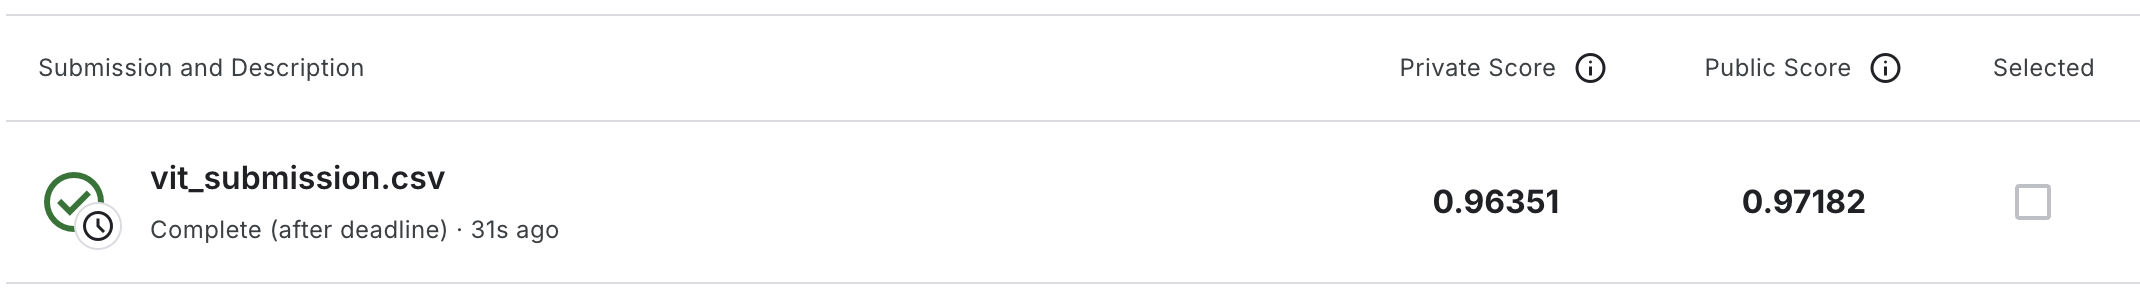

<a id='ast'></a>
# [Theory] AST: Audio Spectrogram Transformer


The Audio Spectrogram Transformer model was proposed in [AST: Audio Spectrogram Transformer](https://arxiv.org/pdf/2104.01778) by Yuan Gong, Yu-An Chung, James Glass. The Audio Spectrogram Transformer applies a Vision Transformer to audio, by turning audio into an image (spectrogram).

![](https://miro.medium.com/v2/resize:fit:802/format:webp/1*ZEJgQriryU_UttuoGC7OFg.png)

The Audio Spectrogram Transformer (AST) architecture is similar to the ViT. Let’s take a closer look:
- Each patch is converted into a 1D embedding of size 768. Positional encoding is added to each embedding to provide information about the position of tokens in the input sequence.
- Each embedding is used as input to the Transformer encoder. The authors retained the original Transformer architecture, which contains 12 layers and 12 attention heads.
- A classification layer is added after the Transformer, consisting of a linear layer with a Sigmoid/Softmax activation.
- The AST reuses the positional embedding of the [CLS] token, allowing the model to learn spatial knowledge from the ViT.

## What changed from ViT to AST?

Despite having similar architectures, there are some differences:

- While the ViT has an input with 3 channels, the AST uses a spectrogram with only 1 channel. Therefore, the weights corresponding to each of the channels are averaged and used as weights for the single channel in the AST model.
- The ViT model is designed to use a fixed size (224x224 or 384x384), whereas the AST uses a variable size, as the spectrogram dimension varies with the audio duration.
- For the AST, a new classification layer is used since the output needs to be adjusted for the new task.

## Adapting positional embeddings

To adapt the positional embedding, the authors proposed using cut and bilinear interpolation. In ViT, the image is divided into 24x24 patches, resulting in a total of 576 patches.

In AST, a 10-second audio spectrogram is divided into 12x100 patches. But how is this value obtained? This is where the cropping and bilinear interpolation method comes in. We won’t go into the mathematical details, but here is the high-level explanation:

- The first dimension of the ViT positional embedding (24) is reduced to 12.
- The second dimension is interpolated from 24 to 100 (applying bilinear interpolation), adjusting to the number of patches in the audio spectrogram.
Visually, it would look approximately like the figure below:

![](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*1lhXRXzzaNtrfVSRVgL7dQ.png)


## Ablation Studies

- **Impact of using ImageNet pretraining:** The ImageNet-pretrained AST outperforms the randomly initialized AST in balanced and full AudioSet experiments.
- **Impact of adapted positional embeddings:** The authors concluded that randomly reinitializing the positional embeddings leads to a drop in performance compared to the interpolation method.
- **Impact of overlapping:** The authors found that overlapping by 6 units improves performance. However, increasing this overlap leads to longer patch sequences for the Transformer to process, which quadratically increases the computational cost.
- **Patch size:** Comparing different patch sizes, the authors concluded that smaller patches result in better model performance. Although rectangular patches (128x2) perform better when trained from scratch, the lack of models with this configuration makes 16x16 dimensions a more practical solution.

<a id='hubert'></a>
# [Theory] HuBERT: Self-Supervised Speech Representation Learning by Masked Prediction of Hidden Units

HuBERT = Hidden-unit BERT. 

HuBERT is basically “BERT for speech”, but with a clever twist - it learns discrete “hidden units” from raw audio without any labels, and then uses them as targets for a BERT-style masked prediction objective. It addresses the challenges of multiple sound units per utterance, no lexicon during pre-training, and variable-length sound units without explicit segmentation.

## Problem: speech is continuous, labels are expensive

**In text, BERT works great because:**
- We already have discrete tokens (subwords).
- We have tons of unlabeled text.
- Masked language modeling = “guess the <missing> word from context.”

**In speech:**
- The signal is continuous waveforms or features, not discrete tokens.
- There is no natural “vocabulary” of units like words.
- Getting phoneme/word labels is expensive.

## Big picture: what is HuBERT?

High-level idea:
1. Take raw audio → convert to continuous features (e.g., MFCC / log-mel).
2. Cluster these features with k-means to get pseudo-labels (“hidden units”) for each time step.
3. Train a Transformer encoder with a BERT-style masked prediction objective:
    - Mask some spans of frames.
    - Predict the cluster IDs of masked frames from their context.
    - (Optionally) Iterate: use the trained HuBERT’s internal features as better inputs to re-cluster, get improved labels, and train again.

So the "supervision" is self-generated: discrete codes from clustering continuous data.

## Discover "hidden units" targets through clustering

The first step is to extract the hidden units (pseudo-targets) from the raw waveform of the audio. The K-means algorithm is used to assign each segment of audio (25 milliseconds) into one of K clusters. Each identified cluster will then become a hidden unit, and all audio frames assigned to this cluster will be assigned with this unit label. Each hidden unit is then mapped to its corresponding embedding vector that can be used during the second step to make predictions.

The most important decision for clustering is into which features to transform the waveform for clustering. Mel-Frequency Cepstral Coefficients (MFCCs) are used for the first clustering step, as these features have been shown to be relatively efficient for speech processing. However, for subsequent clustering steps, representations from an intermediate layer of the HuBERT transformer encoder (from the previous iteration) are re-used.

![](https://jonathanbgn.com/assets/images/illustrated-hubert/hubert_clustering.png)

## Predict noisy targets from the context

This step is the same as for the original BERT: training with the masked language modeling objective. Around 50% of transformer encoder input features are masked, and the model is asked to predict the targets for these positions. The cross-entropy loss is then used to penalize wrong predictions.
![](https://jonathanbgn.com/assets/images/illustrated-hubert/hubert_pretraining_prediction.png)

<a id='data2vec'></a>
# [Theory] Data2Vec: A General Framework for Self-supervised Learning in Speech, Vision and Language


## Big picture: what is Data2vec?

Data2vec’s idea:
- Use one unified SSL objective for speech, images, and text.
- Don’t predict discrete units; instead predict continuous, contextualized hidden states of a Transformer (latent vectors that already encode global context).

Data2vec uses a teacher–student Transformer:<br>
Teacher model
- Same architecture as the student.
- Sees the full, unmasked input.
- Its weights are an exponential moving average (EMA) of the student’s weights (so it’s a slowly changing “target network”). 

Student model
- Same architecture.
- Sees a masked version of the input (some patches/frames/tokens are hidden or dropped).
- Trained to match the teacher’s latent representations on the masked positions.

Training target
- For each token/patch/time step, the target is the average of the top K layers of the teacher at that position, with some normalization. This gives a contextualized latent vector that already “sees” the whole input via self-attention. 
- So instead of “guess which word / code / pixel goes here”, the student learns “make your hidden state look like what a full-context teacher would produce here”.

![](https://www.unite.ai/wp-content/uploads/2023/07/2-2.png)

## Model

- Uses a **standard Transformer** backbone.
- **Vision:** ViT-style model with non-overlapping $16 \times 16$ image patches.
- **Speech:** Raw 16 kHz audio is first encoded with a multi-layer 1D CNN.
- **Text:** Subword tokenization (BPE / WordPiece style). RoBERTa is used as the Transformer backbone.

### Masking

- Part of the input tokens are masked and replaced with a **learned [MASK] embedding**.
- **Vision:** Follows block masking but masks about 60% of patches.
- **Speech:** Masks spans of latent speech frames:
  - With probability $p = 0.065$, a time-step is chosen as a start index.
  - Mask the next 10 time-steps.
  - Roughly 49% of time-steps are masked.
- **Language:** BERT-style masking:
  - 15% of tokens masked

### Training Targets

- Targets are **contextualized representations** (teacher outputs), not discrete symbols.

### Teacher Parameterization

- The **teacher** network is an **EMA (exponential moving average)** of the student parameters.
- Feature encoder and positional encoder parameters are shared between teacher and student.

Teacher parameters at step $t$:

$$
\theta_{\text{teacher}}^{(t)} 
= \tau \, \theta_{\text{teacher}}^{(t-1)} 
+ (1 - \tau) \, \theta_{\text{student}}^{(t-1)},
$$

where:
- $\theta_{\text{teacher}}^{(t)}$ — teacher parameters at step $t$,
- $\theta_{\text{student}}^{(t-1)}$ — student parameters (used as the new value),
- $\tau \in [0, 1)$ — EMA decay (e.g. 0.99 or 0.999).

### Targets

- Training targets come from the **top-$K$** Transformer blocks of the teacher, for time-steps that are masked on the student side.
- Let $a_t^{(l)}$ be output of block $l$ at time-step $t$.
  - Apply normalization to each block output, obtaining $\hat{a}_t^{(l)}$.
  - Average the top $K$ normalized blocks to form the target $y_t$.
- Normalization helps avoid representation collapse.

### Objectives

- Given contextualized targets $y_t$, the student regresses them using **Smooth L1 loss**:
  - Less sensitive to outliers than plain L2.
- For speech, plain **L2 loss** already works well.



## Intuition

Student learns to adjust its weights such that masked-input representations become closer to full-input representations (teacher).

Because mask pattern changes every sample, the only way to do well across the dataset is to learn something stable about the mapping from input patterns → representations.

If student tried to “memorize” random targets sample-by-sample, it would fail because:
- Masking keeps changing.
- There’s weight sharing across positions.
- Same input can appear in many contexts across batches.


So the easiest way to reduce loss is to **learn representations** that are predictive of teacher features across many masks and many samples, not pure memorization.

# References

## ViT
- https://arxiv.org/pdf/2010.11929/1000
- https://sthalles.github.io/an-intuitive-introduction-to-the-vision-transformer
- https://theaisummer.com/vision-transformer
- https://blog.roboflow.com/vision-transformers

## AST
- https://arxiv.org/pdf/2104.01778
- https://medium.com/@ariadnematos/diving-into-the-audio-spectrogram-transformer-c114eae569b7
- https://sh-tsang.medium.com/review-ast-audio-spectrogram-transformer-a108a5775d2f

## HuBERT
- https://arxiv.org/pdf/2106.07447
- https://huggingface.co/docs/transformers/model_doc/hubert
- https://sh-tsang.medium.com/brief-review-hubert-self-supervised-speech-representation-learning-by-masked-prediction-of-e8baf7909c4a
- https://jonathanbgn.com/2021/10/30/hubert-visually-explained.html
  
## Data2Vec
- https://arxiv.org/pdf/2202.03555
- https://sh-tsang.medium.com/brief-review-data2vec-a-general-framework-for-self-supervised-learning-in-speech-vision-and-683e7287db08
- https://blog.paperspace.com/data2vec/